# ReadmitIQ · Feature engineering and validation baselines

**Phase 3.** Reproducible patient-isolated development with a locked final test set.
No tuning, resampling, probability calibration, threshold optimization or test evaluation.
The notebook imports reusable package functions rather than duplicating training code.
Eleven fixed experiments answer prespecified questions; this is not a parameter search.

## 1. Objective

### Question

Which model families and feature choices deserve deeper development after Phase 2?

### Result

In [1]:
import json
import os
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'configs/config.yaml').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '2')

from readmit_iq.modeling.features import FeatureBuilder, feature_columns
from readmit_iq.modeling.pipelines import build_pipeline
from readmit_iq.modeling.reports import build_reports
from readmit_iq.modeling.settings import settings
from readmit_iq.modeling.splitting import load_development, prepare_frozen_partitions
from readmit_iq.modeling.train import run_experiments

_, policy = settings()
OUT = ROOT / policy['modeling']['report_dir']
FIG = ROOT / policy['modeling']['figure_dir']
pd.set_option('display.max_columns', 16)
pd.set_option('display.max_rows', 65)

def read_table(name):
    return pd.read_csv(OUT / f'{name}.csv', keep_default_na=False, na_values=[''])

def figure(name):
    display(Image(filename=str(FIG / f'{name}.png'), width=1000))

display(pd.DataFrame(policy['experiments']).fillna('unweighted / not applicable'))

,name,family,variant,role,class_weight
0,naive_prevalence,dummy,primary,baseline,unweighted / not applicable
1,logistic,logistic,primary,primary,unweighted / not applicable
2,logistic_balanced,logistic,primary,primary,balanced
3,random_forest,forest,primary,primary,unweighted / not applicable
4,histogram_boosting,boosting,primary,primary,unweighted / not applicable
5,logistic_no_utilization,logistic,no_utilization,ablation,unweighted / not applicable
6,logistic_raw_utilization,logistic,raw_utilization,ablation,unweighted / not applicable
7,logistic_no_disposition,logistic,no_disposition,ablation,unweighted / not applicable
8,logistic_diagnosis_groups,logistic,diagnosis_groups,sensitivity,unweighted / not applicable
9,logistic_diagnosis_raw,logistic,diagnosis_raw,sensitivity,unweighted / not applicable


### Interpretation

Average precision is prioritized with ~11% positives. The question is patient-isolated predictive value for confirmed-discharge outreach, not clinical benefit.

### Decision

Use prevalence, logistic (unweighted/balanced), random forest and histogram boosting, plus six bounded feature/timing fits. The installed environment supports these families; no optional booster stack or MLflow is needed for this finite registry.

## 2. Load frozen partitions

### Question

Are patients isolated and all eligible encounters allocated exactly once?

### Result

In [2]:
lock = prepare_frozen_partitions()
train = load_development('train')
validation = load_development('validation')
# Test is not opened; display only the aggregate diagnostics saved when splitting.
display(pd.DataFrame(lock['partitions']).round(3))
display(pd.Series(lock['patient_overlap'], name='patient_overlap'))
assert all(value == 0 for value in lock['patient_overlap'].values())
assert set(train.patient_nbr).isdisjoint(validation.patient_nbr)
assert len(train) + len(validation) + lock['partitions'][2]['encounters'] == 90702
try:
    load_development('test')
except ValueError as error:
    print(error)
else:
    raise AssertionError('Test guard failed')

,partition,encounters,patients,positives,negatives,prevalence_pct,encounter_pct,patient_pct
0,train,63563,45530,7068,56495,11.120,70.079,69.999
1,validation,13590,9757,1499,12091,11.030,14.983,15.001
2,test,13549,9757,1487,12062,10.975,14.938,15.001


train_validation    0
train_test          0
validation_test     0
Name: patient_overlap, dtype: int64

Test partition is locked; Phase 3 permits train and validation only


### Interpretation

Train/validation/test contain **63,563 / 13,590 / 13,549 encounters** and **45,530 / 9,757 / 9,757 patients**. Prevalence is **11.120% / 11.030% / 10.975%**. All patient overlaps are zero. The source/cohort/partition hashes and seed 42 are frozen.

### Decision

Fit preprocessing and estimators on training; use validation for development. Test labels were used only for allocation diagnostics before locking. Full-cohort Phase 2 EDA indirectly exposed future test outcomes, so this is not a completely unseen confirmatory sample. No dates or hospital IDs support temporal/site validation.

## 3. Feature decisions

### Question

What may enter a confirmed-discharge score, and what remains uncertain?

### Result

In [3]:
numeric, categorical = feature_columns('primary')
display(pd.DataFrame({'feature': numeric + categorical,
                     'type': ['numeric']*len(numeric) + ['categorical']*len(categorical)}))
features = FeatureBuilder().transform(train)
assert not {'patient_nbr','encounter_id','readmitted','readmitted_lt30','weight','diag_1','payer_code'} & set(features)
display(pd.Series({'primary_source_fields': 10, 'derived_utilization_terms': 4,
                   'numeric_missing_values': int(features[numeric].isna().sum().sum())}))

,feature,type
0,time_in_hospital,numeric
1,number_inpatient,numeric
2,number_emergency,numeric
3,number_outpatient,numeric
4,total_prior_utilization,numeric
5,any_prior_inpatient,numeric
6,any_prior_emergency,numeric
7,any_prior_outpatient,numeric
8,age,categorical
9,gender,categorical


primary_source_fields        10
derived_utilization_terms     4
numeric_missing_values        0
dtype: int64

### Interpretation

Primary inputs are age band, gender, admission type/source, admitting specialty, confirmed disposition, stay length and three provided prior-year utilization counts. The total (sum) and any-use indicators are candidates. IDs, targets, constants, weight and race are excluded from predictors; race is audit-only. Final diagnoses, billing, procedures, treatment summaries and labs are sensitivity-only.

### Decision

Score at confirmed discharge. Disposition is conditional on knowing the destination before outreach assignment, never on later billing corrections. Keep the frozen postacute eligibility policy. Never derive future repeat status or chronology from IDs. See the [scoring contract](../reports/modeling/scoring_time_contract.md).

## 4. Preprocessing

### Question

How do the families receive suitable features without learning from held-out data?

### Result

In [4]:
spec = next(e for e in policy['experiments'] if e['name'] == 'logistic')
print(build_pipeline(spec, policy))
print('Numeric source counts are complete; no numerical imputer is fitted.')
print('Rare levels: training count < 100 -> Other; protect Unknown/Not measured and intact age bands.')

Pipeline(steps=[('features', FeatureBuilder()),
                ('preprocess',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('numeric', StandardScaler(),
                                                  ['time_in_hospital',
                                                   'number_inpatient',
                                                   'number_emergency',
                                                   'number_outpatient',
                                                   'total_prior_utilization',
                                                   'any_prior_inpatient',
                                                   'any_prior_emergency',
                                                   'any_prior_outpatient']),
                                                 ('categorical',
                                                  CategoryEncoder(),
                                                  ['age', 'gend

### Interpretation

FeatureBuilder and ColumnTransformer precede every estimator. Logistic scales numeric counts and one-hot encodes training-pooled categories. Forest uses unscaled counts and the same categorical strategy. Boosting receives unscaled counts and explicitly categorical ordinal IDs, not artificial numerical ordering.

### Decision

Fit vocabularies/scalers on training only. Unseen categories map to Other. Missing/nonfinite numeric counts fail explicitly. Age remains categorical rather than an invented midpoint or forced linear trend. Disable boosting early stopping to avoid an internal encounter-level split.

## 5. Baseline

### Question

How much does logistic regression improve over predicting training prevalence for everyone?

### Result

In [5]:
# Reproduce the complete fixed registry through reusable modules.
summary = run_experiments()
build_reports()
results = read_table('baseline_model_results')
differences = read_table('feature_ablation_results')
metrics = ['name','average_precision','roc_auc','recall','precision','f1','specificity','brier']
display(results.loc[results.name.isin(['naive_prevalence','logistic']), metrics].round(3))
assert summary['test_evaluated'] is False and summary['threshold_optimized'] is False

2026-09-22 16:21:15,642 INFO readmit_iq.modeling.splitting: Verified frozen partition hashes; no test table opened


2026-09-22 16:21:15,882 INFO readmit_iq.modeling.train: Fitting naive_prevalence: dummy / primary


2026-09-22 16:21:16,251 INFO readmit_iq.modeling.train: naive_prevalence validation AP=0.1103 Brier=0.0981 (0.4s)


2026-09-22 16:21:16,251 INFO readmit_iq.modeling.train: Fitting logistic: logistic / primary


2026-09-22 16:21:16,689 INFO readmit_iq.modeling.train: logistic validation AP=0.1943 Brier=0.0951 (0.4s)


...

2026-09-22 16:21:25,098 INFO readmit_iq.modeling.train: logistic_diagnosis_raw validation AP=0.1983 Brier=0.0949 (0.6s)


2026-09-22 16:21:25,099 INFO readmit_iq.modeling.train: Fitting logistic_encounter_summaries: logistic / encounter_summaries


2026-09-22 16:21:26,066 INFO readmit_iq.modeling.train: logistic_encounter_summaries validation AP=0.1947 Brier=0.0950 (1.0s)


2026-09-22 16:21:26,068 INFO readmit_iq.modeling.train: Computing 300 paired patient bootstrap replicates


,name,average_precision,roc_auc,recall,precision,f1,specificity,brier
6,logistic,0.194,0.653,0.004,0.462,0.008,0.999,0.095
10,naive_prevalence,0.110,0.500,0.000,0.000,0.000,1.000,0.098


### Interpretation

Validation AP is **0.110** for prevalence and **0.194** for logistic: +0.084 (paired patient-bootstrap interval 0.070–0.101), about 1.76× baseline. Brier improves from 0.098 to 0.095. AP is non-interpolated average precision, not trapezoidal PR area.

### Decision

Keep logistic as the reference. Do not select on accuracy. Threshold 0.50 is diagnostic only; precision is recorded as zero when there are no positive predictions. No operating point is optimized.

## 6. First-pass models

### Question

Do nonlinear models provide enough gain to justify further experimentation?

### Result

,name,average_precision,roc_auc,recall,precision,f1,specificity,brier,ap_ci_low,ap_ci_high,encoded_features
0,histogram_boosting,0.202,0.662,0.005,0.538,0.009,1.000,0.094,0.185,0.220,14
2,random_forest,0.197,0.658,0.000,0.000,0.000,1.000,0.095,0.181,0.218,81
6,logistic,0.194,0.653,0.004,0.462,0.008,0.999,0.095,0.178,0.213,81
7,logistic_balanced,0.194,0.654,0.532,0.172,0.260,0.683,0.226,0.177,0.213,81
10,naive_prevalence,0.110,0.500,0.000,0.000,0.000,1.000,0.098,0.105,0.116,81


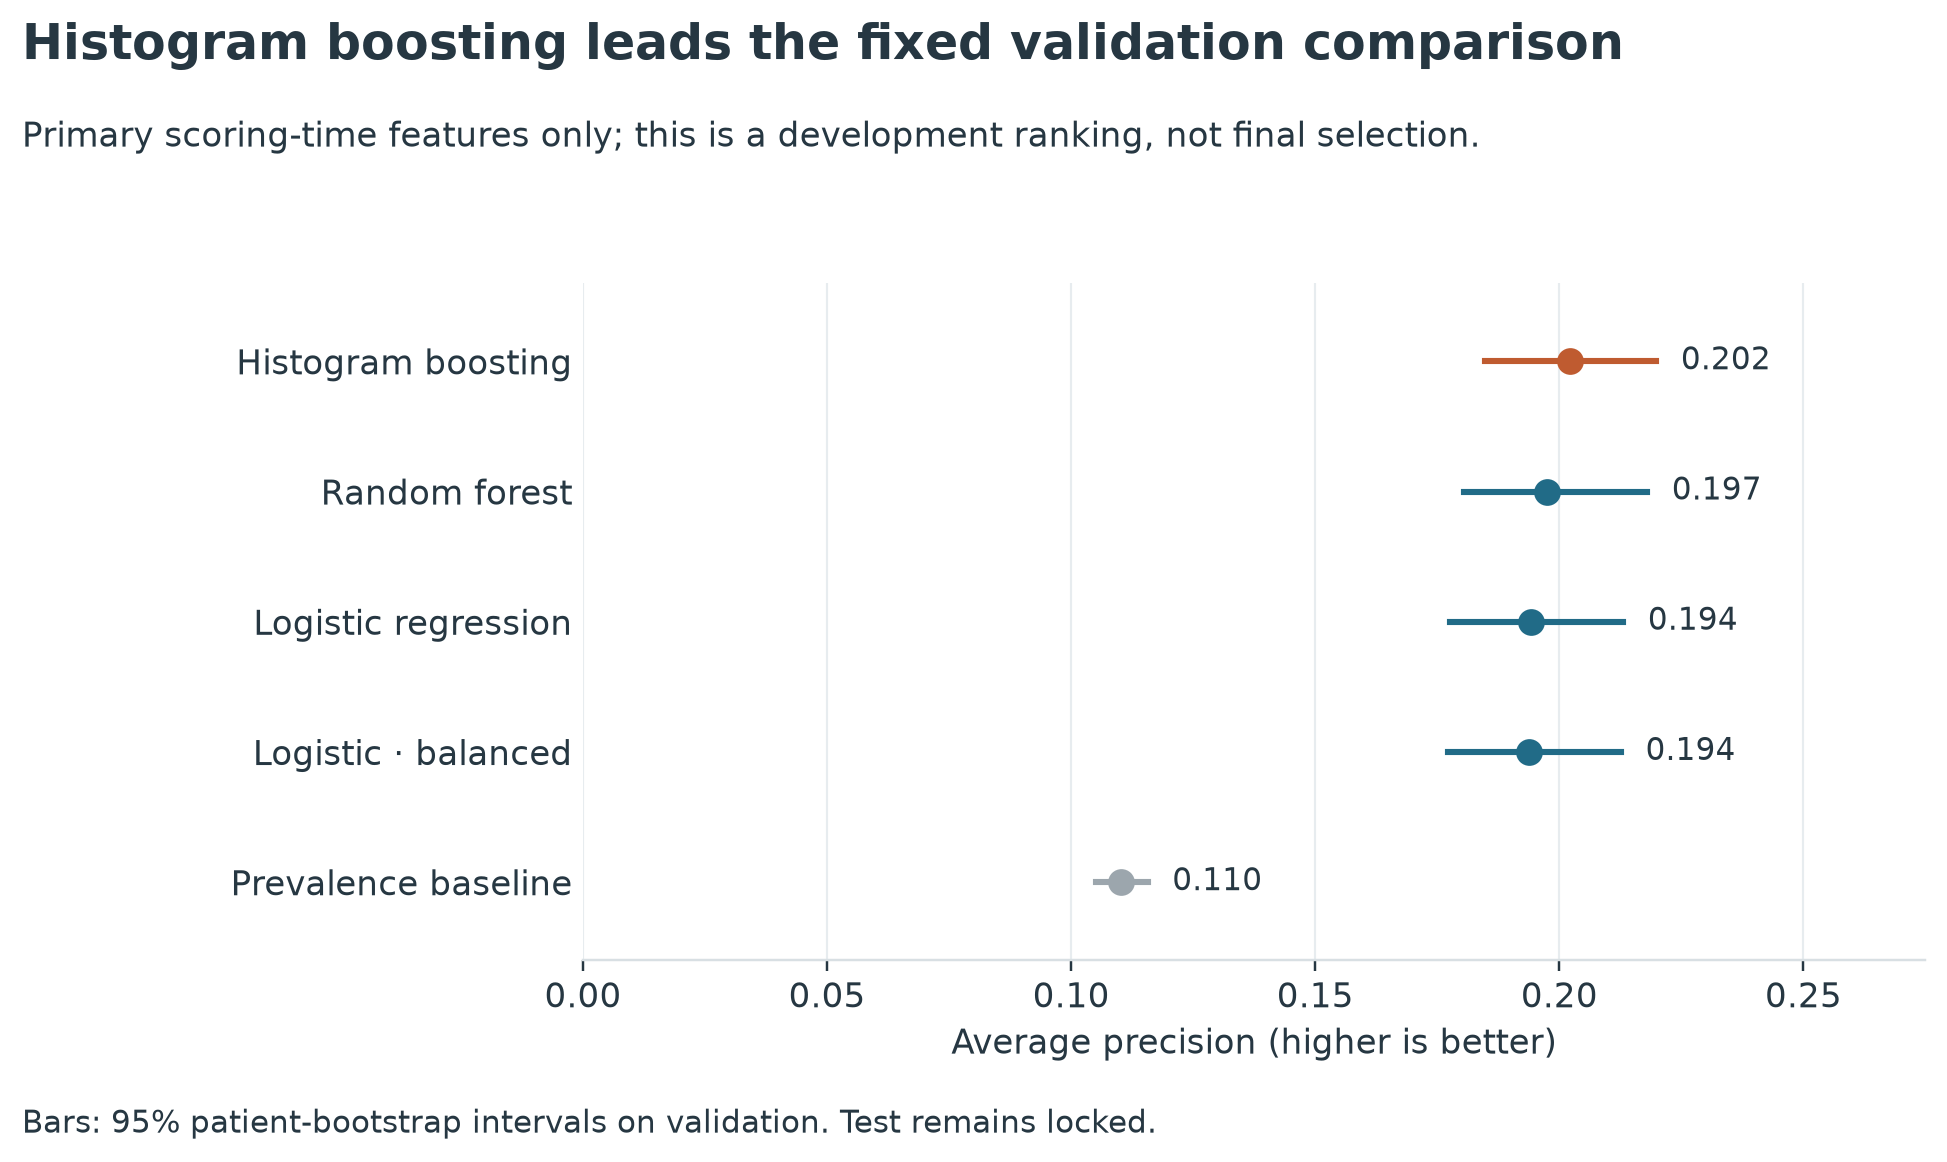

,comparison,model,reference,ap_difference,ci_low,ci_high
4,Balanced class weights,logistic_balanced,logistic,-0.0004,-0.0013,0.0007
5,Random forest vs logistic,random_forest,logistic,0.0032,-0.0034,0.0106
6,Boosting vs logistic,histogram_boosting,logistic,0.0079,0.0015,0.0143


In [6]:
primary = results.loc[results.role.isin(['primary','baseline'])]
display(primary[metrics + ['ap_ci_low','ap_ci_high','encoded_features']].round(3))
figure('01_model_comparison')
display(differences.loc[differences.comparison.isin(
    ['Boosting vs logistic','Random forest vs logistic','Balanced class weights'])].round(4))

### Interpretation

Boosting leads with **AP 0.202, ROC-AUC 0.662 and Brier 0.0945**. Its +0.0079 AP over matched logistic has interval 0.0015–0.0143: a modest gain. Forest reaches 0.197 AP; its +0.0032 difference interval crosses zero. Balanced logistic has essentially unchanged AP and Brier 0.226.

### Decision

Prioritize boosting and logistic in Phase 4; forest is a lower-priority reference. Balanced weights raise recall at 0.50 to 0.532 with precision 0.172, but that does not establish a better precision–recall frontier than an unweighted model at another threshold. No current evidence supports automatic SMOTE.

## 7. Feature ablation

### Question

Do utilization engineering, disposition and clinical grouping add predictive value?

### Result

,comparison,model,reference,ap_difference,ci_low,ci_high
0,Logistic vs prevalence,logistic,naive_prevalence,0.0840,0.0698,0.1012
1,All prior utilization,logistic,logistic_no_utilization,0.0394,0.0267,0.0555
2,Add total and any-use indicators,logistic,logistic_raw_utilization,-0.0021,-0.0052,0.0001
3,Discharge destination,logistic,logistic_no_disposition,0.0143,0.0078,0.0212
4,Balanced class weights,logistic_balanced,logistic,-0.0004,-0.0013,0.0007
5,Random forest vs logistic,random_forest,logistic,0.0032,-0.0034,0.0106
6,Boosting vs logistic,histogram_boosting,logistic,0.0079,0.0015,0.0143
7,Add grouped diagnoses (uncertain timing),logistic_diagnosis_groups,logistic,0.0017,-0.0016,0.0051
8,Raw vs grouped diagnosis representation,logistic_diagnosis_raw,logistic_diagnosis_groups,0.0023,-0.0058,0.0101
9,Add encounter summaries (uncertain timing),logistic_encounter_summaries,logistic,0.0004,-0.0024,0.0034


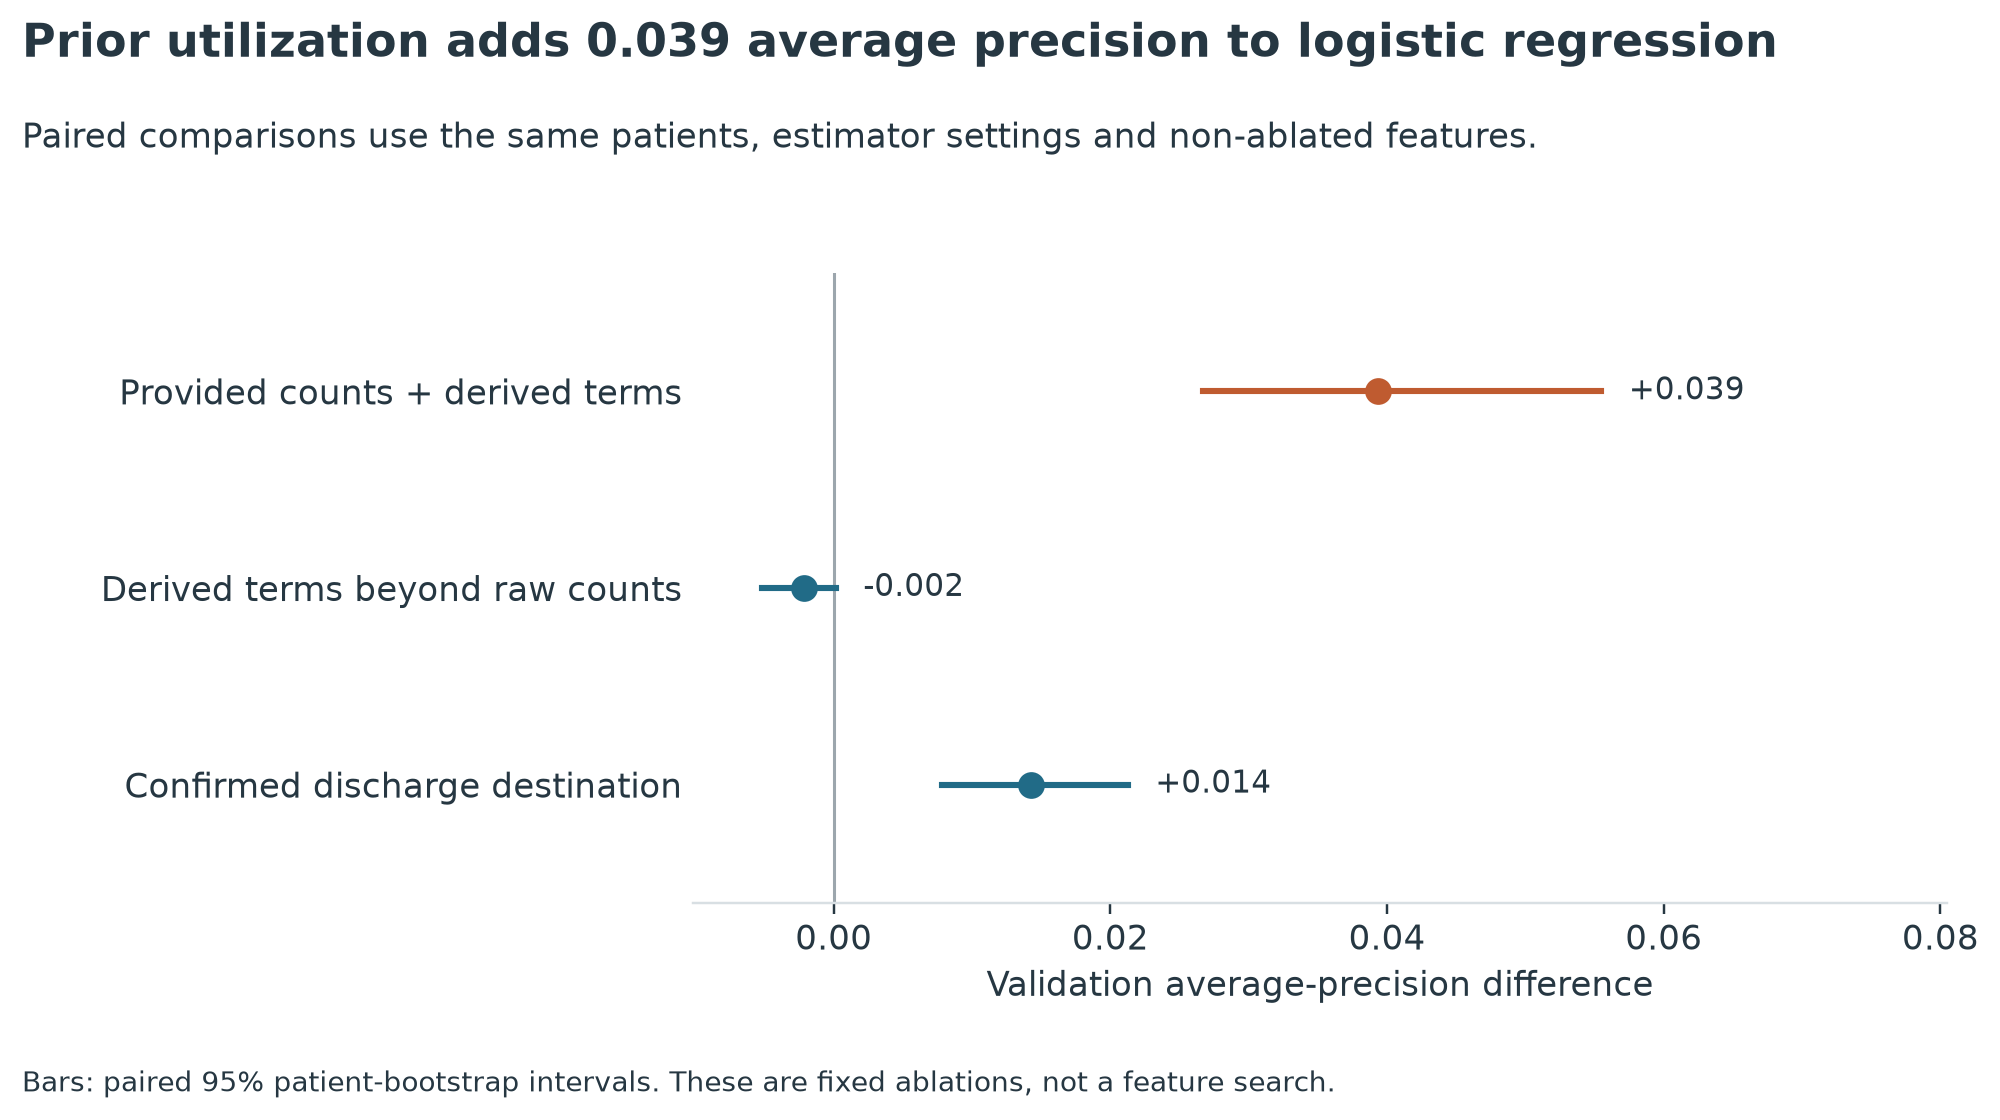

,name,average_precision,roc_auc,recall,precision,f1,specificity,brier,encoded_features
1,logistic_diagnosis_raw,0.198,0.657,0.009,0.412,0.018,0.998,0.095,382
4,logistic_diagnosis_groups,0.196,0.658,0.004,0.300,0.008,0.999,0.095,118
5,logistic_encounter_summaries,0.195,0.653,0.005,0.350,0.009,0.999,0.095,135


status
Excluded                         7
Excluded from predictors         1
Primary allowed                 10
Primary engineered candidate     4
Sensitivity derivation only     20
Sensitivity only                15
Name: feature_rows, dtype: int64

In [7]:
display(differences.round(4))
figure('04_utilization_ablation')
display(results.loc[results.role.eq('sensitivity'), metrics + ['encoded_features']].round(3))
display(read_table('model_feature_manifest').groupby('status').size().rename('feature_rows'))

### Interpretation

Removing utilization lowers logistic AP from **0.194 to 0.155**; its contribution is +0.039 (0.027–0.055). Raw counts alone achieve **0.196**: the total/any-use package adds −0.002 (−0.0052 to +0.0001), with no demonstrated gain. Disposition adds +0.014 (0.008–0.021).

Diagnosis groups achieve 0.196 versus 0.198 for raw strings, but the difference interval includes zero. Encoding uses **118 versus 382 columns**. Encounter summaries add only +0.0004 with an interval crossing zero. These timing-sensitive fits are ineligible for primary selection.

### Decision

Keep separate raw utilization counts for the next logistic reference. The joint ablation does not isolate individual derived terms. Diagnosis ranges follow [Strack et al., Table 3](https://onlinelibrary.wiley.com/doi/10.1155/2014/781670), extended explicitly to secondary/tertiary positions. Do not promote uncertain fields without a timing audit. Medication counts use Steady/Up/Down as active and Up/Down as changed; they count source fields, not ingredients or change events.

## 8. Validation comparison

### Question

What do precision–recall and calibration indicate about using these risk scores?

### Result

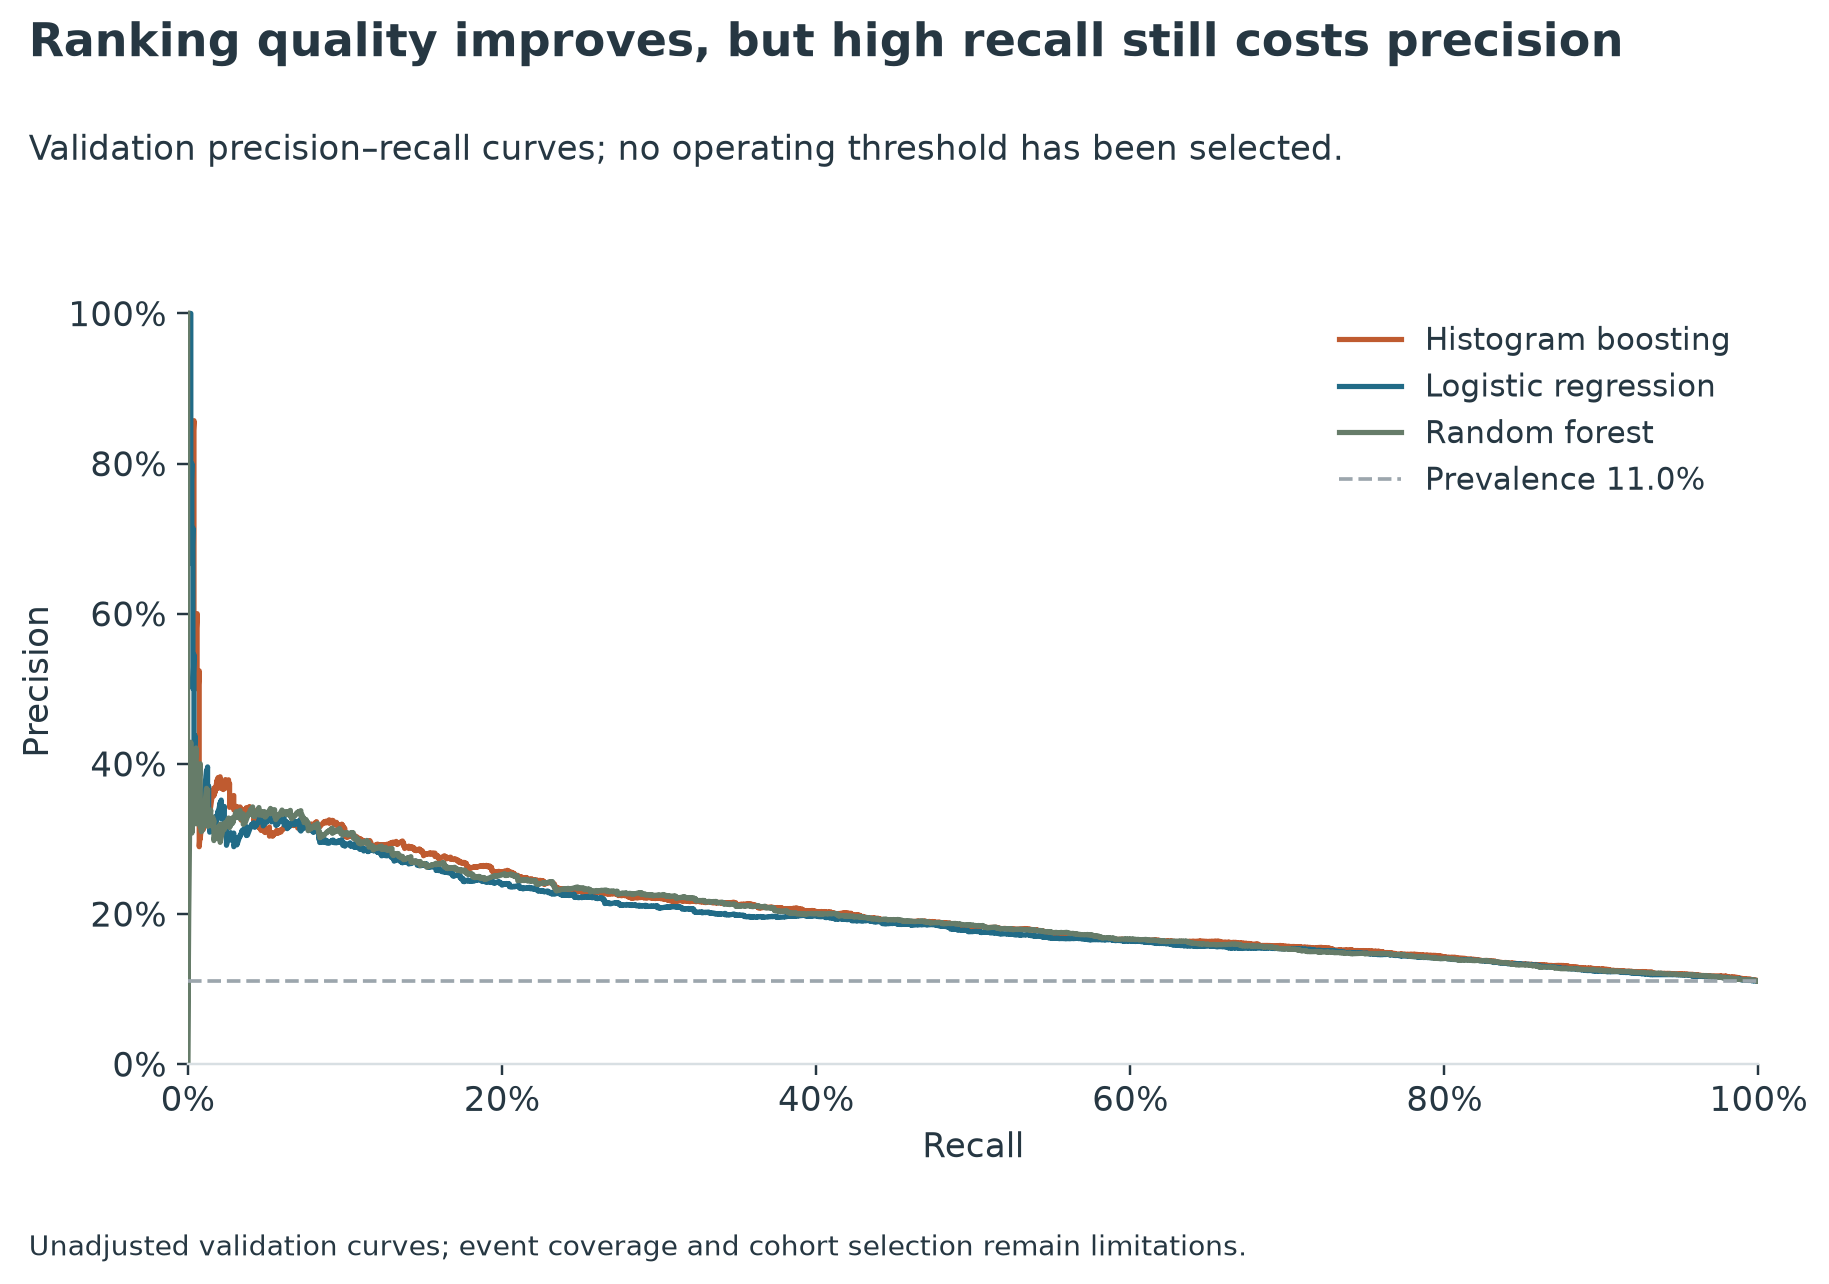

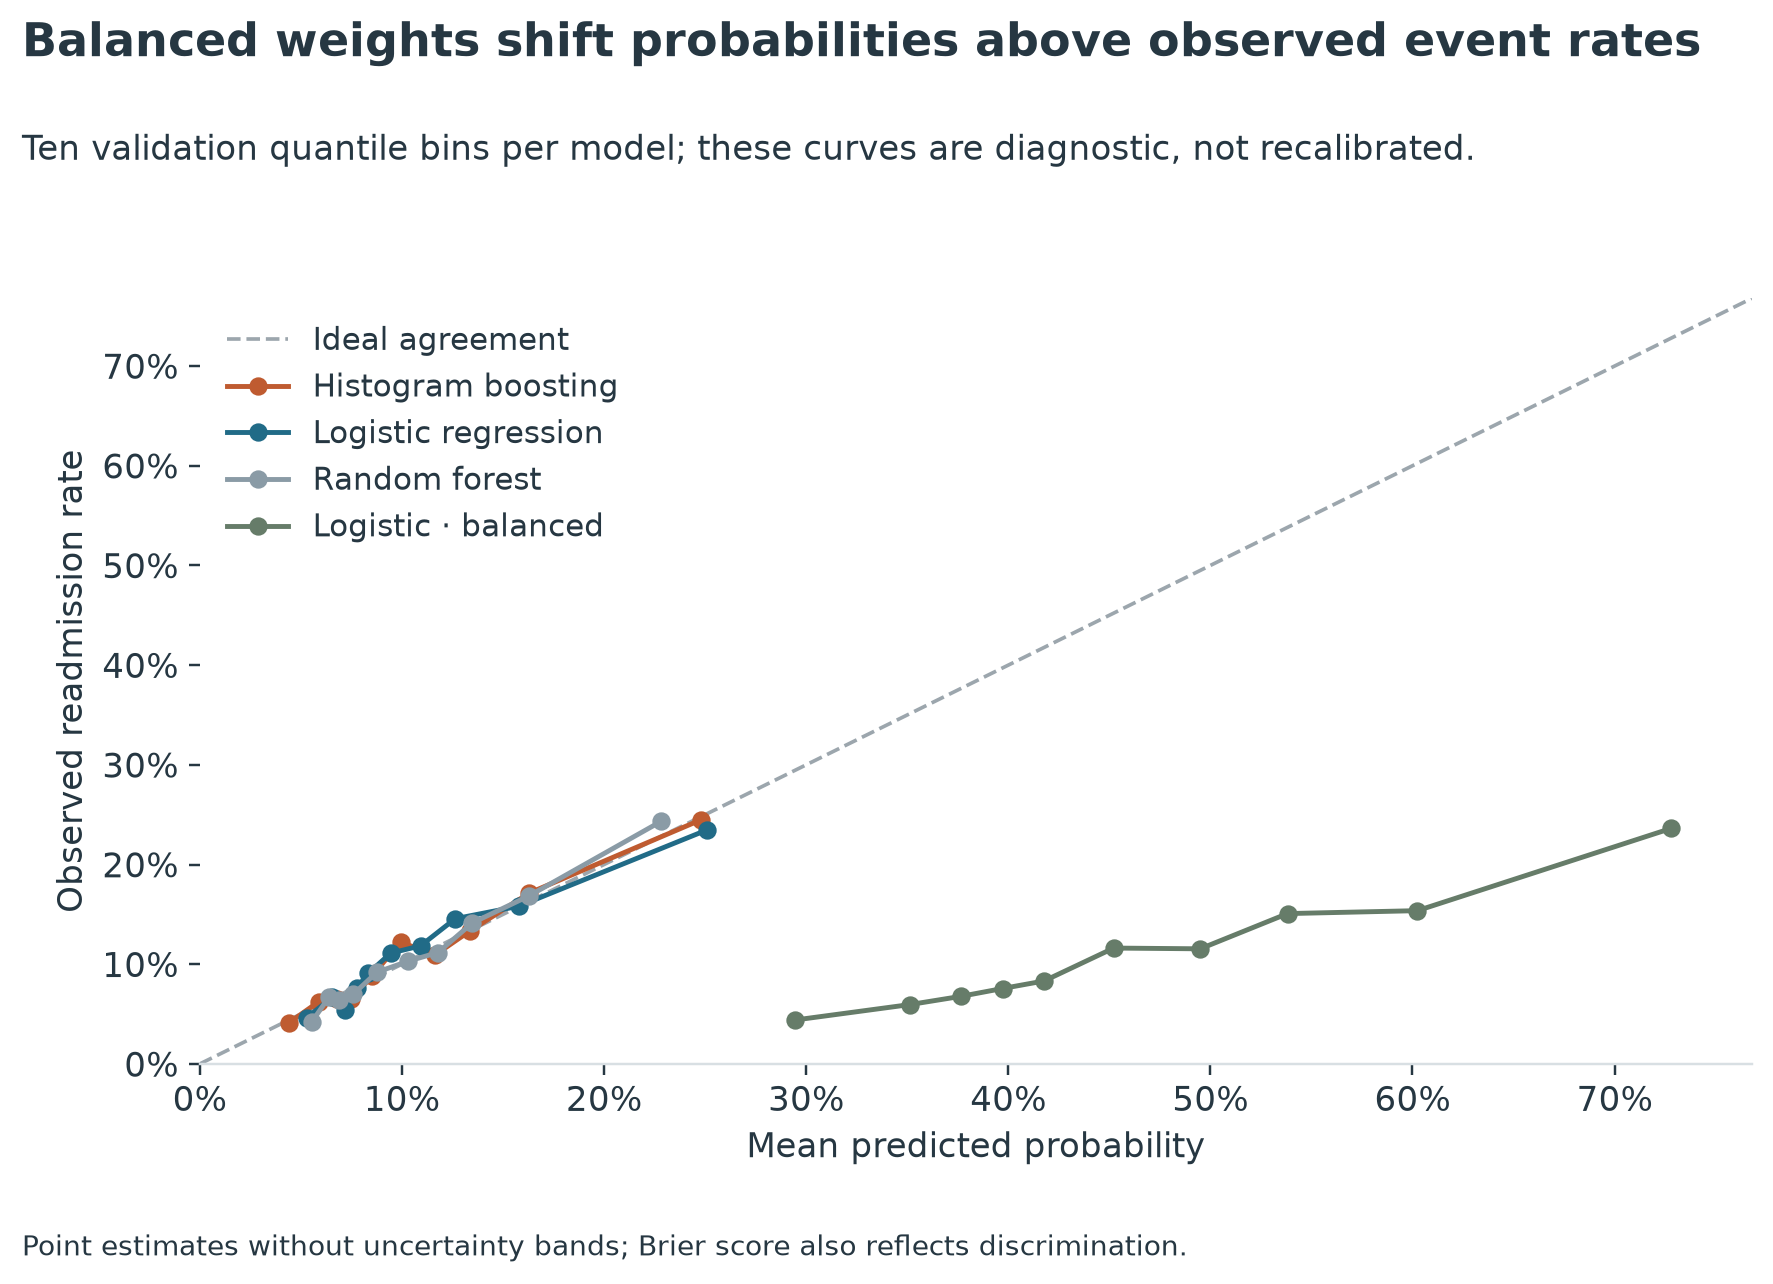

,name,mean_probability,prevalence,brier,tn,fp,fn,tp,threshold
0,histogram_boosting,0.1092,0.1103,0.0945,12085,6,1492,7,0.5
2,random_forest,0.1099,0.1103,0.0947,12091,0,1499,0,0.5
6,logistic,0.1091,0.1103,0.0951,12084,7,1493,6,0.5
7,logistic_balanced,0.4653,0.1103,0.2258,8256,3835,702,797,0.5
10,naive_prevalence,0.1112,0.1103,0.0981,12091,0,1499,0,0.5


,model,bin,encounters,mean_probability,observed_rate,positives
0,histogram_boosting,"(0.0133, 0.0546]",1359,0.0440,0.0412,56
1,histogram_boosting,"(0.0546, 0.0635]",1360,0.0589,0.0625,85
2,histogram_boosting,"(0.0635, 0.0721]",1422,0.0680,0.0647,92
3,histogram_boosting,"(0.0721, 0.0788]",1295,0.0750,0.0649,84
4,histogram_boosting,"(0.0788, 0.0926]",1359,0.0853,0.0883,120
5,histogram_boosting,"(0.0926, 0.107]",1359,0.0994,0.1221,166
6,histogram_boosting,"(0.107, 0.125]",1360,0.1166,0.1096,149
7,histogram_boosting,"(0.125, 0.146]",1358,0.1336,0.1333,181
8,histogram_boosting,"(0.146, 0.182]",1359,0.1631,0.1714,233
9,histogram_boosting,"(0.182, 0.553]",1359,0.2482,0.2450,333


In [8]:
figure('02_precision_recall')
figure('03_initial_calibration')
display(primary[['name','mean_probability','prevalence','brier','tn','fp','fn','tp','threshold']].round(4))
display(read_table('calibration_bins').round(4))

### Interpretation

Ranking improves over prevalence, but precision falls as recall rises. Mean risk is **10.92% for boosting**, **10.91% for logistic**, versus **11.03% observed**. Quantile curves show local deviations. Balanced logistic predicts **46.53% on average**, greatly overstating absolute risk. Brier combines calibration and discrimination; bin curves have no uncertainty bands.

### Decision

Do not declare calibration solved from mean agreement. Study probability calibration and operating policies in Phase 4 using group-aware development data. No calibrator, final threshold or business optimization was fitted.

## 9. Initial error analysis

### Question

Which validation errors deserve attention before selecting an outreach policy?

### Result

In [9]:
errors = read_table('validation_error_groups')
display(errors.loc[errors.group.isin(['prior_inpatient','discharge_disposition',
                                     'specialty_coverage','payer_coverage'])].round(4))

,group,level,encounters,positives,negatives,tp,fp,fn,tn,recall,false_positive_rate,mean_probability,predicted_positives
0,prior_inpatient,0,9134,779,8355,0,0,779,8355,0.0000,0.0000,0.0837,0
1,prior_inpatient,1,2569,310,2259,0,0,310,2259,0.0000,0.0000,0.1266,0
2,prior_inpatient,2,1001,184,817,0,0,184,817,0.0000,0.0000,0.1743,0
3,prior_inpatient,3+,886,226,660,7,6,219,654,0.0310,0.0091,0.2476,13
8,discharge_disposition,1,8983,822,8161,4,5,818,8156,0.0049,0.0006,0.0925,9
9,discharge_disposition,22,289,76,213,2,0,74,213,0.0263,0.0000,0.2592,2
10,discharge_disposition,24,5,0,5,0,0,0,5,NaN,0.0000,0.1006,0
11,discharge_disposition,3,2097,304,1793,0,0,304,1793,0.0000,0.0000,0.1450,0
12,discharge_disposition,4,102,18,84,0,0,18,84,0.0000,0.0000,0.1218,0
13,discharge_disposition,6,1985,258,1727,1,1,257,1726,0.0039,0.0006,0.1234,2


### Interpretation

At 0.50, boosting predicts only **13 positives: 7 true positives and 6 false positives**, missing **1,492/1,499 events**. All 13 calls have 3+ provided prior inpatient visits, yet **219/226 events in that group are still missed**. Five false positives are home and one is home-health; six cases cannot establish a stable destination pattern.

Specialty-unknown misses are 773/776 versus 719/723 observed; payer-unknown misses are 566/569 versus 926/930. Near-universal negative predictions dominate these patterns. Mean risk rises from 8.37% at no prior inpatient use to 24.76% at 3+.

### Decision

The main hypothesis is that 0.50 is unsuitable for outreach with an ~11% event rate. Defer threshold work. Do not infer missingness mechanisms or fairness from these sparse calls; later examine subgroup calibration/errors with patient uncertainty and a meaningful development-only policy.

## 10. Phase 4 recommendation

### Question

What should proceed, and what remains unresolved?

### Result

In [10]:
assert summary['models_fitted'] == 11
assert summary['evaluated_partition'] == 'validation'
assert summary['test_evaluated'] is False
display(pd.Series({'development_winner': summary['development_winner'],
                   'recommended_families': 'histogram gradient boosting; logistic regression',
                   'test_evaluated': summary['test_evaluated'],
                   'tracking': summary['tracking']}))
display(Markdown((OUT / 'phase4_recommendation.md').read_text()))

development_winner                                     histogram_boosting
recommended_families     histogram gradient boosting; logistic regression
test_evaluated                                                      False
tracking                Fixed 11-experiment YAML registry plus CSV/JSO...
dtype: object

# Phase 4 recommendation from validation evidence

Prioritize **histogram gradient boosting and logistic regression**. Keep random forest as a
lower-priority reference, not a required tuning track: its AP advantage over logistic is
uncertain, while boosting has a modest positive paired difference. The best validation model
is a development candidate only. No final test evaluation or production model exists.

1. Carry forward the frozen patient assignments and confirmed-discharge feature contract.
   Use patient-grouped training folds for future parameter comparisons. Preserve validation
   for bounded development decisions and keep test locked until the final pipeline is fixed.
2. Start the logistic track from separate raw utilization counts: the total/any-use package
   showed no benefit. Retain all three counts; do not infer a strict monotonic constraint.
   Validate whether redundant derived terms are also unnecessary for boosting inside training.
3. Tune a small regularization/complexity range only in the next authorized phase. Favor the
   two observed promising families over importing many similarly motivated boosters now.
4. Assess calibration with group-aware out-of-fold training predictions. Weighted logistic
   probability distortion needs attention if weighting is pursued; AP currently offers no reason
   to prefer it. No current evidence justifies SMOTE.
5. Later choose an outreach threshold using costs/capacity and development data. At 0.50,
   boosting misses 99.53% of positive encounters, including most high-utilization cases.
   Do not mistake low default-threshold recall for absence of ranking value, or balanced-model
   recall for an improved precision–recall frontier.
6. Require a timing audit before adding final diagnoses, billing, lab or treatment summaries.
   Grouped diagnoses are more compact, but raw versus grouped performance is inconclusive.
   Encounter-summary gain is negligible. Neither sensitivity result overrides the contract.
7. Review subgroup calibration/error rates with patient uncertainty after choosing a meaningful
   development-only operating policy. Current tiny positive-call counts are inadequate for
   stable subgroup conclusions. Excluding race as a predictor does not establish fairness.

Unresolved operational questions: actual source-field arrival timestamps, availability of
confirmed destination before outreach allocation, suitability of mixed rehabilitation cases,
out-of-network outcome ascertainment and contemporary external validation. Cohort scope stays
fixed throughout current development; changing it requires an explicit versioned redesign.

No tuning, resampling, final calibration, SHAP, threshold optimization, API or deployment was
performed in Phase 3. Do not start those steps automatically.


### Interpretation

Two tracks are justified: boosting for its modest nonlinear gain, and logistic with raw utilization counts as the simpler reference. Forest remains a comparator. Broad diagnosis groups are compact but not proven better; redundant utilization additions and encounter summaries have no demonstrated gain.

### Decision

Keep test frozen. Further work requires separate authorization: grouped training-fold tuning, calibration and an outreach policy. Resolve field arrival timestamps, mixed rehabilitation workflow fit and external outcome coverage before deployment claims. No tuning, SHAP, SMOTE, final test evaluation, API or production model was created. See the [full report](../reports/modeling/baseline_model_report.md), [feature manifest](../reports/modeling/model_feature_manifest.md) and [Phase 4 recommendation](../reports/modeling/phase4_recommendation.md).